#  **Análisis de utilidades de implementación de proyectos de sostenibilidad en Chrysal**
**OBJETIVO:** Definir rentabilidad anual en la implementación de proyectos de sostenibilidad y revisar si la inversion esta generando mayores ingresos.

## 1. 🧩 **Cargar y Explorar - Visión General Automatizado**

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sales = pd.read_csv("Tabla1_Chrysal_sustainability (2).csv")
marketing = pd.read_csv("Tabla2_Marketing_Campaign.csv")
costs = pd.read_csv("Tabla3_Costs.csv")

In [65]:
sales_clean = sales.copy()
marketing_clean = marketing.copy()
costs_clean = costs.copy()

In [66]:
# explorar datasets automatizado
datasets = {
    "SALES": sales_clean,
    "COSTS": costs_clean,
    "MARKETING": marketing_clean
}
def mostrar_heads(datasets):
    for nombre, df in datasets.items():
        print(f"\n=== {nombre} ===")
        print(df.head(10))
mostrar_heads(datasets)




=== SALES ===
  sales_order_number       fecha      pais  product_reference  campaign_id  \
0          SO-000001  2023-03-23     Kenya  Chrysal Protect Y            3   
1          SO-000002  2024-12-06  Colombia     Chrysal Grow X            1   
2          SO-000003  2024-08-19     Kenya     Chrysal Root R            4   
3          SO-000004  2024-02-05     Kenya     Chrysal Grow X            4   
4          SO-000005  2024-01-30   Holanda     Chrysal Root R            2   
5          SO-000006  2025-02-22     Kenya  Chrysal Protect Y            2   
6          SO-000007  2023-03-20   Ecuador    Chrysal Flora F            1   
7          SO-000008  2024-09-27   Ecuador     Chrysal Root R            4   
8          SO-000009  2023-07-03     Kenya    Chrysal Boost Z            4   
9          SO-000010  2023-03-27     Kenya  Chrysal Protect Y            4   

     category_product  sales_revenue  production_cost_usd  
0         Nutricional       52807.07              51180.4  
1     

In [67]:
sales_clean["Date"] = pd.to_datetime(sales_clean["fecha"], errors="coerce", utc=True)
sales_clean["Year"]  = sales_clean["Date"].dt.year
sales_clean["Month"] = sales_clean["Date"].dt.month
sales_clean.head()

,sales_order_number,fecha,pais,product_reference,campaign_id,category_product,sales_revenue,production_cost_usd,Date,Year,Month
0,SO-000001,2023-03-23,Kenya,Chrysal Protect Y,3,Nutricional,52807.07,51180.4,2023-03-23 00:00:00+00:00,2023,3
1,SO-000002,2024-12-06,Colombia,Chrysal Grow X,1,Nutricional,93797.01,50638.4,2024-12-06 00:00:00+00:00,2024,12
2,SO-000003,2024-08-19,Kenya,Chrysal Root R,4,Nutricional,77864.99,51530.7,2024-08-19 00:00:00+00:00,2024,8
3,SO-000004,2024-02-05,Kenya,Chrysal Grow X,4,Fertilizante,30000.00,51272.5,2024-02-05 00:00:00+00:00,2024,2
4,SO-000005,2024-01-30,Holanda,Chrysal Root R,2,Nutricional,70709.19,51151.0,2024-01-30 00:00:00+00:00,2024,1


In [68]:
# explorar datasets automatizado

def mostrar_info(datasets):
    for nombre, df in datasets.items():
        print(f"\n=== {nombre} ===")
        print(df.info())
mostrar_info(datasets)




=== SALES ===
<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   sales_order_number   700 non-null    str                
 1   fecha                700 non-null    str                
 2   pais                 700 non-null    str                
 3   product_reference    700 non-null    str                
 4   campaign_id          700 non-null    int64              
 5   category_product     700 non-null    str                
 6   sales_revenue        700 non-null    float64            
 7   production_cost_usd  700 non-null    float64            
 8   Date                 700 non-null    datetime64[us, UTC]
 9   Year                 700 non-null    int32              
 10  Month                700 non-null    int32              
dtypes: datetime64[us, UTC](1), float64(2), int32(2), int64(1), str(5)
memory usage: 

In [69]:
# explorar datasets automatizado

def mostrar_unicos(datasets):
    for nombre, df in datasets.items():
        print(f"\n=== {nombre} ===")
        print(df.nunique())
mostrar_unicos(datasets)




=== SALES ===
sales_order_number     700
fecha                  480
pais                     4
product_reference        5
campaign_id              4
category_product         5
sales_revenue          647
production_cost_usd    685
Date                   480
Year                     3
Month                   12
dtype: int64

=== COSTS ===
Sales_order_number     700
Product_reference        5
Waste_kg               664
Disposal_waste_cost    664
dtype: int64

=== MARKETING ===
Marketing_cost             4
Campaign_ID                4
Marketing_campaign_type    4
dtype: int64


In [70]:
marketing_clean["Marketing_campaign_type"].value_counts()

Marketing_campaign_type
Social Media        2
Influencers Agro    2
Field Campaign      2
Email Marketing     2
Name: count, dtype: int64

In [71]:
marketing_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Marketing_cost           8 non-null      float64
 1   Campaign_ID              8 non-null      int64  
 2   Marketing_campaign_type  8 non-null      str    
dtypes: float64(1), int64(1), str(1)
memory usage: 324.0 bytes


In [72]:
marketing_clean.duplicated().sum()

np.int64(4)

In [73]:
marketing_clean[marketing_clean.duplicated(keep=False)].sort_values(['Marketing_cost']).head()

,Marketing_cost,Campaign_ID,Marketing_campaign_type
1,3000.0,3,Influencers Agro
3,3000.0,3,Influencers Agro
6,4000.0,1,Email Marketing
7,4000.0,1,Email Marketing
2,11000.0,4,Social Media


### **Eliminacion de duplicados en marketing_clean**

In [74]:
marketing_clean  = marketing_clean.drop_duplicates(keep="first").reset_index(drop=True)
# Validación rápida (debería ser 0)
marketing_clean.duplicated().sum()

np.int64(0)

## **1.2 🧩 Identificación de problemas de calidad de datos**
Calcule la cantidad de vacios en "sales" y "costs"

In [75]:
sales_clean.isna().sum()
print('Numero de nulos',sales_clean.isna().sum())
print('Porcentaje de nulos',sales_clean.isna().mean())

Numero de nulos sales_order_number     0
fecha                  0
pais                   0
product_reference      0
campaign_id            0
category_product       0
sales_revenue          0
production_cost_usd    0
Date                   0
Year                   0
Month                  0
dtype: int64
Porcentaje de nulos sales_order_number     0.0
fecha                  0.0
pais                   0.0
product_reference      0.0
campaign_id            0.0
category_product       0.0
sales_revenue          0.0
production_cost_usd    0.0
Date                   0.0
Year                   0.0
Month                  0.0
dtype: float64


In [76]:
costs_clean.isna().sum()
print('Porcentaje de nulos',costs_clean.isna().sum())
print('Porcentaje de nulos',costs_clean.isna().mean())


Porcentaje de nulos Sales_order_number      0
Product_reference       0
Waste_kg               35
Disposal_waste_cost    35
dtype: int64
Porcentaje de nulos Sales_order_number     0.00
Product_reference      0.00
Waste_kg               0.05
Disposal_waste_cost    0.05
dtype: float64


In [77]:
costs_clean.nunique()

Sales_order_number     700
Product_reference        5
Waste_kg               664
Disposal_waste_cost    664
dtype: int64

##**CONCLUSION**
1.1- No e evidenciaron datos vacios en la tabla de "sales_clean" y solo se evidencio 5% de vacios en la tabla de "cost_clean".


In [78]:
costs_clean['Disposal_waste_cost'].isna().groupby(costs_clean['Product_reference']).sum().sort_values(ascending=False)

Product_reference
Chrysal Flora F      11
Chrysal Protect Y     9
Chrysal Grow X        7
Chrysal Root R        5
Chrysal Boost Z       3
Name: Disposal_waste_cost, dtype: int64

### **Analisis de vacios**
1.2- En la tabla anterior se observa que el producto Chrysal Flora F tiene 11 datos vacios de 35 que es aprox el 34 % de los datos. Por tal razon no son faltantes al azar sino que algo ocurrio en Chrysal Flora F que no tiene la informacion completa.

# **2- Estadistica Descriptiva**

In [79]:
print("sales",sales_clean.describe())
print("marketing",marketing_clean.describe())
print("costs",costs_clean.describe())

sales        campaign_id  sales_revenue  production_cost_usd         Year  \
count   700.000000     700.000000           700.000000   700.000000   
mean      2.364286  100167.831271         50956.599714  2023.818571   
std       1.114418   74722.284338           701.025571     0.739213   
min       1.000000   30000.000000         48799.400000  2023.000000   
25%       1.000000   57298.940000         50498.100000  2023.000000   
50%       2.000000   80902.620000         50970.550000  2024.000000   
75%       3.000000  111959.010000         51414.375000  2024.000000   
max       4.000000  500862.070000         53000.200000  2025.000000   

            Month  
count  700.000000  
mean     5.848571  
std      3.408722  
min      1.000000  
25%      3.000000  
50%      5.000000  
75%      9.000000  
max     12.000000  
marketing        Marketing_cost  Campaign_ID
count        4.000000     4.000000
mean     19500.000000     2.500000
std      27233.557731     1.290994
min       3000.000000   

## **2.1 Analisis complementario**
### **2.1.1 Realice pruebas de comparacion de media y mediana** para entender la tendencia de "Sales_revenue_USD" y "production_costs" en tabla de "sales_clean"


**HALLAZGOS:**
- **Sales Revenue USD**: De acuerdo a analisis intercuartil IQR se evidencia un sesgo a la derecha "outlier" ya que el "max" es 5 veces que el valor del "75%"
- **Production_cost**: Posiblemente distribucion normal
- **Waste_kg** y **Disposal_waste_cost**: posiblemente tiene un sesgo a la derecha "outlier" ya que el "max" es el doble que el valor del "75%"

In [80]:
columnas_numericas_sales = sales_clean[['sales_revenue', 'production_cost_usd']]

# Include 'Disposal_waste_cost' from sales_final in the numeric columns for analysis
columnas_numericas_sales['Disposal_waste_cost'] = costs_clean['Disposal_waste_cost']

for col in columnas_numericas_sales:
    # Media y mediana de cada columna
    print(col)
    print("Promedio", columnas_numericas_sales[col].mean(),"- Mediana:", columnas_numericas_sales[col].median())
    print()

sales_revenue
Promedio 100167.83127142857 - Mediana: 80902.62

production_cost_usd
Promedio 50956.59971428571 - Mediana: 50970.55

Disposal_waste_cost
Promedio 457.38503759398486 - Mediana: 403.345



## **CONCLUSIONES:**

### **Diferencias entre mediana y promedio**

- Se evidencia tendencia de sesgo a la derecha para "Sales_revenue" por tal razon se debe caracterizar los valores y definir si hay outliers.
- En "production_cost_usd" NO se evidencia diferencia sifnificativa entre mediana y promedio.
- En "Disposal_waste_cost" Hay una diferencia ligera entre mediana y promedio. Es indispensable revisar el histograma para ver como se completan los datos vacios.



### 2.1.3 Realice evaluacion **agrupando por año y pais** para revisar dominancia en la columna "Sales_revenue_USD"

> Añadir blockquote



In [81]:
resumen_pais = (
    sales_clean
    .groupby(['pais'])
    .agg(
        avg_sales=('sales_revenue', 'mean'),
        count_sales=('sales_revenue', 'count'),
        desv_sales=('sales_revenue', 'std'),
        min_sales=('sales_revenue', 'min'),
        max_sales=('sales_revenue', 'max'),

    )
    .reset_index()
)
resumen_pais

,pais,avg_sales,count_sales,desv_sales,min_sales,max_sales
0,Colombia,82769.863631,179,30209.441806,30000.0,183621.39
1,Ecuador,77466.501629,178,26950.455697,30000.0,150674.64
2,Holanda,169424.290491,163,122809.722233,30000.0,500862.07
3,Kenya,77202.664778,180,28541.542200,30000.0,152800.03


**CONCLUSIONES**:

Se evidencia dominancia de tendencia de Holanda posiblemente por el efecto del Euro y la capacidad de pago mayor en Europa. La diferencia en ventas de Holanda con respecto a Colombia, Ecuador y Kenya es de **cinco veces mayor en Holanda**.

In [82]:
columnas_categoricas_1 = sales_clean[['pais','product_reference','category_product']]
columnas_categoricas_2 = marketing_clean[['Marketing_campaign_type']]

print(columnas_categoricas_1.describe())
print(columnas_categoricas_2.describe())


         pais product_reference category_product
count     700               700              700
unique      4                 5                5
top     Kenya   Chrysal Flora F     Fertilizante
freq      180               182              160
       Marketing_campaign_type
count                        4
unique                       4
top               Social Media
freq                         1


In [83]:
for col in columnas_categoricas_1:
    print(col)
    print(sales_clean[col].value_counts())
    print()

pais
pais
Kenya       180
Colombia    179
Ecuador     178
Holanda     163
Name: count, dtype: int64

product_reference
product_reference
Chrysal Flora F      182
Chrysal Boost Z      155
Chrysal Grow X       135
Chrysal Root R       126
Chrysal Protect Y    102
Name: count, dtype: int64

category_product
category_product
Fertilizante          160
Regulador de creci    145
Fungicida             136
Insecticida           130
Nutricional           129
Name: count, dtype: int64



In [84]:
print(marketing_clean["Marketing_campaign_type"].value_counts())

Marketing_campaign_type
Social Media        1
Influencers Agro    1
Field Campaign      1
Email Marketing     1
Name: count, dtype: int64


**CONCLUSION DE ANALISIS:**




De acuerdo a este conteo de columnas **categóricas dominantes**  **NO** se evidencia una afectacion especifica por alguna categoria evaluada.

## **3- Visualizacion Diagnóstica**

In [85]:
sales_paises = sales_clean[(sales_clean['pais']=='Colombia') |
                  (sales_clean['pais']=='Holanda') |
                  (sales_clean['pais']=='Kenya') |
                  (sales_clean['pais']=='Ecuador')
]
sales_paises

,sales_order_number,fecha,pais,product_reference,campaign_id,category_product,sales_revenue,production_cost_usd,Date,Year,Month
0,SO-000001,2023-03-23,Kenya,Chrysal Protect Y,3,Nutricional,52807.07,51180.4,2023-03-23 00:00:00+00:00,2023,3
1,SO-000002,2024-12-06,Colombia,Chrysal Grow X,1,Nutricional,93797.01,50638.4,2024-12-06 00:00:00+00:00,2024,12
2,SO-000003,2024-08-19,Kenya,Chrysal Root R,4,Nutricional,77864.99,51530.7,2024-08-19 00:00:00+00:00,2024,8
3,SO-000004,2024-02-05,Kenya,Chrysal Grow X,4,Fertilizante,30000.00,51272.5,2024-02-05 00:00:00+00:00,2024,2
4,SO-000005,2024-01-30,Holanda,Chrysal Root R,2,Nutricional,70709.19,51151.0,2024-01-30 00:00:00+00:00,2024,1
...,...,...,...,...,...,...,...,...,...,...,...
695,SO-000696,2023-08-20,Holanda,Chrysal Protect Y,2,Nutricional,30000.00,50935.6,2023-08-20 00:00:00+00:00,2023,8
696,SO-000697,2024-10-20,Colombia,Chrysal Protect Y,1,Nutricional,133568.62,50697.6,2024-10-20 00:00:00+00:00,2024,10
697,SO-000698,2024-06-22,Ecuador,Chrysal Boost Z,2,Nutricional,106604.79,50330.5,2024-06-22 00:00:00+00:00,2024,6
698,SO-000699,2023-02-15,Ecuador,Chrysal Boost Z,2,Fertilizante,59649.50,52441.8,2023-02-15 00:00:00+00:00,2023,2


In [86]:
costs_referencia = costs_clean[(costs_clean['Product_reference']=='Chrysal Flora F') |
                             (costs_clean['Product_reference']=='Chrysal Grow X') |
                               (costs_clean['Product_reference']=='Chrysal Root R') |
                                (costs_clean['Product_reference']=='Chrysal Protect Y') |
                               (costs_clean['Product_reference']=='Chrysal Boost Z')
]
costs_referencia


,Sales_order_number,Product_reference,Waste_kg,Disposal_waste_cost
0,SO-000001,Chrysal Grow X,750.32,375.160
1,SO-000002,Chrysal Flora F,209.94,104.970
2,SO-000003,Chrysal Flora F,882.49,441.245
3,SO-000004,Chrysal Flora F,982.56,491.280
4,SO-000005,Chrysal Grow X,582.48,291.240
...,...,...,...,...
695,SO-000696,Chrysal Boost Z,605.26,302.630
696,SO-000697,Chrysal Grow X,669.30,334.650
697,SO-000698,Chrysal Root R,846.95,423.475
698,SO-000699,Chrysal Flora F,2069.15,1034.575


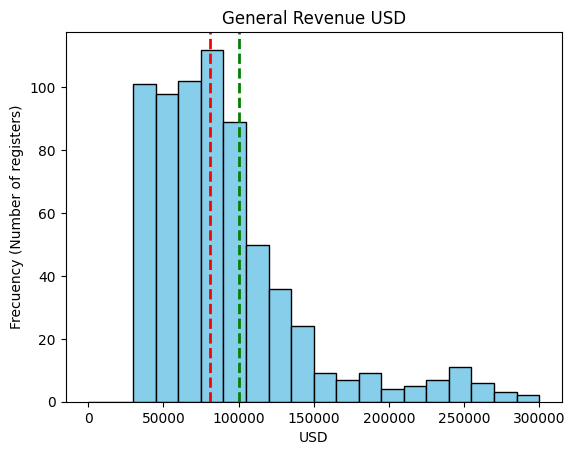

In [87]:
plt.hist(sales_clean['sales_revenue'], bins=20, color='skyblue', edgecolor='black', range=(0,300000)) # figsize=(ancho, alto)
median_sales = sales_clean['sales_revenue'].median()
average_sales = sales_clean['sales_revenue'].mean()

plt.axvline(median_sales, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(average_sales, color='green', linestyle='dashed', linewidth=2, label='Mediana')

plt.title('General Revenue USD')
plt.xlabel('USD')
plt.ylabel('Frecuency (Number of registers)')
plt.show()

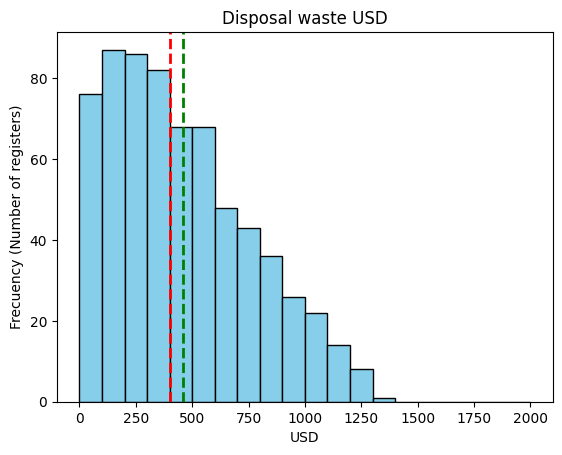

In [88]:
plt.hist(costs_clean['Disposal_waste_cost'], bins=20, color='skyblue', edgecolor='black', range=(0,2000)) # figsize=(ancho, alto)
median_sales = costs_clean['Disposal_waste_cost'].median()
average_sales = costs_clean['Disposal_waste_cost'].mean()

plt.axvline(median_sales, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(average_sales, color='green', linestyle='dashed', linewidth=2, label='Mediana')

plt.title('Disposal waste USD')
plt.xlabel('USD')
plt.ylabel('Frecuency (Number of registers)')
plt.show()

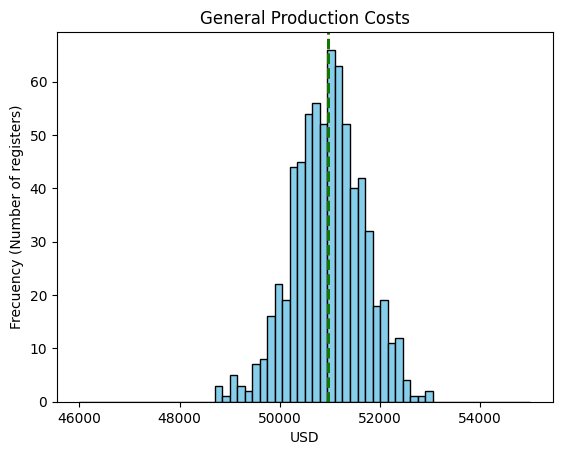

In [89]:
plt.hist(sales_clean['production_cost_usd'], bins=60, color='skyblue', edgecolor='black', range=(46000,55000)) # figsize=(ancho, alto)
median_sales = sales_clean['production_cost_usd'].median()
average_sales = sales_clean['production_cost_usd'].mean()

plt.axvline(median_sales, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(average_sales, color='green', linestyle='dashed', linewidth=2, label='Mediana')

plt.title('General Production Costs')
plt.xlabel('USD')
plt.ylabel('Frecuency (Number of registers)')
plt.show()

##4- Identificacion formal de Outliers
- Se realizara prueba de IQR Indice Intercuartil para entender el comportamiento de los outliers.

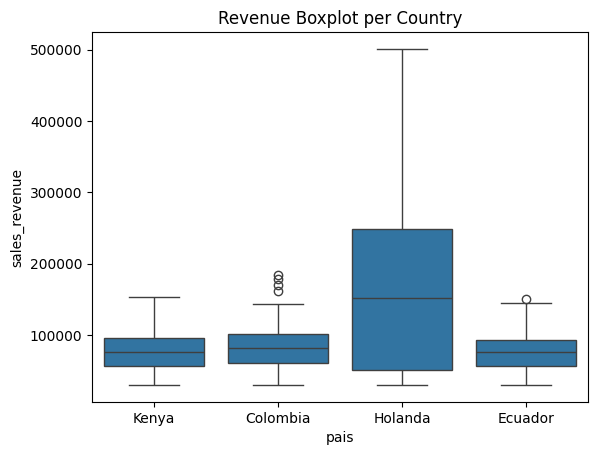

In [90]:
sns.boxplot(data=sales_paises, x="pais", y="sales_revenue")
plt.title(f'Revenue Boxplot per Country')
plt.show()


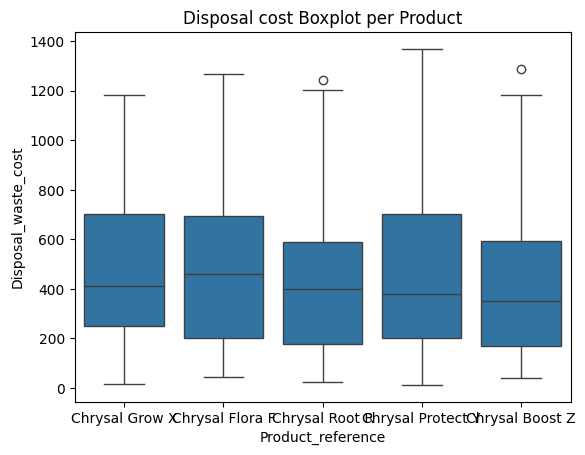

In [91]:
sns.boxplot(data=costs_referencia, x="Product_reference", y="Disposal_waste_cost")
plt.title(f'Disposal cost Boxplot per Product')
plt.show()

###**Conclusiones:**
- Teniendo en cuenta el boxplot por paises es claro que **Holanda no tiene Outliers a pesar de tener los valores mas altos y en cambio Colombia si tiene datos outliers**, que pueden afectar la veracidad de sus mediciones; por tal razon se justifica **wisorizar - capar Outliers de Colombia reemplazando el limite mayor del rango interquartil IQR**.
- Los vacios de "Disposal_waste_cost" no dependenden del tipo de producto por tal razon los vacios en efecto se pueden reemplazar por la mediana por la ligera tendencia a sesgo a la derecha.

1.   Elemento de lista
2.   Elemento de lista



##**5 - Limpieza automatica por pipeline:**

### 5.1 Completar vacios de "Disposal_waste_cost" en la tabla "costs_clean" por la mediana
### 5.2 Quitar los outliers de "Colombia" en la tabla de "sales_clean" de la columna de "sales_revenue" por el metodo de "Indexación"

In [92]:
# Completar vacios de "Disposal waste_cost"
costs_clean['Disposal_waste_cost'] = costs_clean['Disposal_waste_cost'].fillna(costs_clean['Disposal_waste_cost'].median())
print('Porcentaje de nulos',costs_clean.isna().sum())
costs_clean.info()

Porcentaje de nulos Sales_order_number      0
Product_reference       0
Waste_kg               35
Disposal_waste_cost     0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sales_order_number   700 non-null    str    
 1   Product_reference    700 non-null    str    
 2   Waste_kg             665 non-null    float64
 3   Disposal_waste_cost  700 non-null    float64
dtypes: float64(2), str(2)
memory usage: 22.0 KB


In [93]:
# Quitar outliers de Colombia en "sales_revenue"

# Filtrar las ventas de Colombia
colombia = sales_clean[sales_clean["pais"] == "Colombia"]

# Calcular Q1, Q3 e IQR
Q1 = colombia["sales_revenue"].quantile(0.25)
Q3 = colombia["sales_revenue"].quantile(0.75)
IQR = Q3 - Q1

# Límites para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Limite_inferior", limite_inferior)
print("Limite_superior", limite_superior)

Limite_inferior 89.20750000001863
Limite_superior 161344.90749999997


In [94]:
sales_clean.loc[
    (sales_clean["pais"] == "Colombia") &
    (sales_clean["sales_revenue"] > limite_superior),
    "sales_revenue"
] = limite_superior
sales_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   sales_order_number   700 non-null    str                
 1   fecha                700 non-null    str                
 2   pais                 700 non-null    str                
 3   product_reference    700 non-null    str                
 4   campaign_id          700 non-null    int64              
 5   category_product     700 non-null    str                
 6   sales_revenue        700 non-null    float64            
 7   production_cost_usd  700 non-null    float64            
 8   Date                 700 non-null    datetime64[us, UTC]
 9   Year                 700 non-null    int32              
 10  Month                700 non-null    int32              
dtypes: datetime64[us, UTC](1), float64(2), int32(2), int64(1), str(5)
memory usage: 54.8 KB


In [95]:
sales_clean.to_csv("sales_clean.csv", index=False)
costs_clean.to_csv("costs_clean.csv", index=False)
marketing_clean.to_csv("marketing_clean.csv", index=False)

In [96]:
marketing_clean["Campaign_ID"] = marketing_clean["Campaign_ID"].replace({
    1: "Email marketing",
    2: "Field campaign",
    3: "Influencers Agro",
    4: "Social Media"
})

In [97]:
sales_clean["campaign_id"] = sales_clean["campaign_id"].replace({
    1: "Email marketing",
    2: "Field campaign",
    3: "Influencers Agro",
    4: "Social Media"
})

##7- Unificación tabla de interes para calculos de **% Profit y % ROI**.

**- Agregue a la tabla de "Sales_clean" la tabla de "Costs"**

In [98]:
costs_clean.rename(columns={'Sales_order_number': 'sales_order_number'}, inplace=True)
costs_clean_small = costs_clean[['sales_order_number','Disposal_waste_cost']]
costs_clean_small.head()

,sales_order_number,Disposal_waste_cost
0,SO-000001,375.160
1,SO-000002,104.970
2,SO-000003,441.245
3,SO-000004,491.280
4,SO-000005,291.240


In [99]:
sales_clean_small = sales_clean[['sales_order_number','sales_revenue','Year','production_cost_usd','pais','product_reference','campaign_id']]

sales_final = pd.merge(sales_clean_small, costs_clean_small, on=['sales_order_number'], how='left')

sales_final.head()

,sales_order_number,sales_revenue,Year,production_cost_usd,pais,product_reference,campaign_id,Disposal_waste_cost
0,SO-000001,52807.07,2023,51180.4,Kenya,Chrysal Protect Y,Influencers Agro,375.160
1,SO-000002,93797.01,2024,50638.4,Colombia,Chrysal Grow X,Email marketing,104.970
2,SO-000003,77864.99,2024,51530.7,Kenya,Chrysal Root R,Social Media,441.245
3,SO-000004,30000.00,2024,51272.5,Kenya,Chrysal Grow X,Social Media,491.280
4,SO-000005,70709.19,2024,51151.0,Holanda,Chrysal Root R,Field campaign,291.240


In [100]:
# Calculo del costo total

sales_final['costo_total'] = sales_final['production_cost_usd'] + sales_final['Disposal_waste_cost']

In [101]:
sales_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sales_order_number   700 non-null    str    
 1   sales_revenue        700 non-null    float64
 2   Year                 700 non-null    int32  
 3   production_cost_usd  700 non-null    float64
 4   pais                 700 non-null    str    
 5   product_reference    700 non-null    str    
 6   campaign_id          700 non-null    object 
 7   Disposal_waste_cost  700 non-null    float64
 8   costo_total          700 non-null    float64
dtypes: float64(4), int32(1), object(1), str(3)
memory usage: 46.6+ KB


#**Aplica las siguientes formulas para calculo de "gross_profit" por pais :**

- Costo total = Production_costs + Disposal_waste_cost
- Gross profit = Sales_revenus - costo_total
- % profit-margin = ( gross_profit / Sales_revenue_usd ) * 100

In [102]:
sales_final['costo_total'] = sales_final['production_cost_usd'] + sales_final['Disposal_waste_cost']

In [103]:
profit_country = sales_final.groupby('pais').agg(
    sales_revenue=('sales_revenue', 'sum'),
    costo_total=('costo_total', 'sum')
).reset_index()
profit_country


,pais,sales_revenue,costo_total
0,Colombia,14766534.49,9201402.390
1,Ecuador,13789037.29,9145226.965
2,Holanda,27616159.35,8374099.520
3,Kenya,13896479.66,9267169.050


In [104]:
profit_country['gross_profit'] = profit_country['sales_revenue'] - profit_country['costo_total']
profit_country['margin_pct'] = (profit_country['gross_profit']) *100 / profit_country['sales_revenue']
profit_country['margin_pct'] = profit_country['margin_pct'].round(2) # Format to 2 decimal places
profit_country['gross_profit'] = profit_country['gross_profit'].round(2) # Format to 2 decimal places
profit_country

,pais,sales_revenue,costo_total,gross_profit,margin_pct
0,Colombia,14766534.49,9201402.390,5565132.10,37.69
1,Ecuador,13789037.29,9145226.965,4643810.32,33.68
2,Holanda,27616159.35,8374099.520,19242059.83,69.68
3,Kenya,13896479.66,9267169.050,4629310.61,33.31


In [105]:
profit_year = (
    sales_final
    .groupby(['Year'])
    .agg(
        sales_revenue=('sales_revenue', 'sum'),
        costo_total=('costo_total', 'sum')

    )
    .reset_index()
)
profit_year

,Year,sales_revenue,costo_total
0,2023,2.727855e+07,1.368386e+07
1,2024,2.867300e+07,1.517372e+07
2,2025,1.411666e+07,7.130321e+06


In [106]:
profit_year['gross_profit'] = profit_year['sales_revenue'] - profit_year['costo_total']
profit_year['margin_pct'] = (profit_year['gross_profit']) *100 / profit_year['sales_revenue']
profit_year

,Year,sales_revenue,costo_total,gross_profit,margin_pct
0,2023,2.727855e+07,1.368386e+07,1.359469e+07,49.836573
1,2024,2.867300e+07,1.517372e+07,1.349928e+07,47.080107
2,2025,1.411666e+07,7.130321e+06,6.986339e+06,49.490029


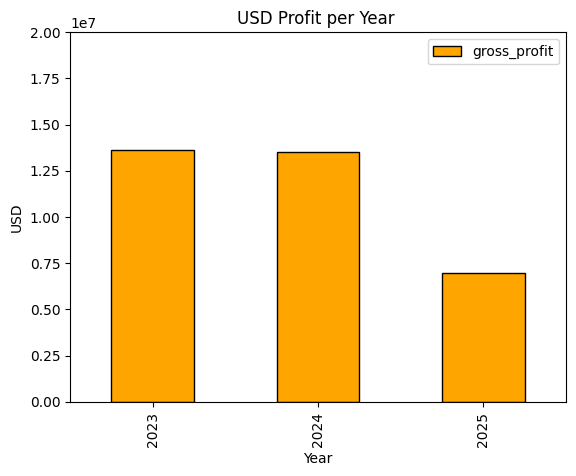

In [107]:
profit_year.plot(x='Year', y=['gross_profit'], kind='bar', color='orange', edgecolor='black')
plt.xticks(rotation=90)
plt.title('USD Profit per Year ')
plt.ylabel('USD')
plt.ylim(0,20000000)
plt.show()

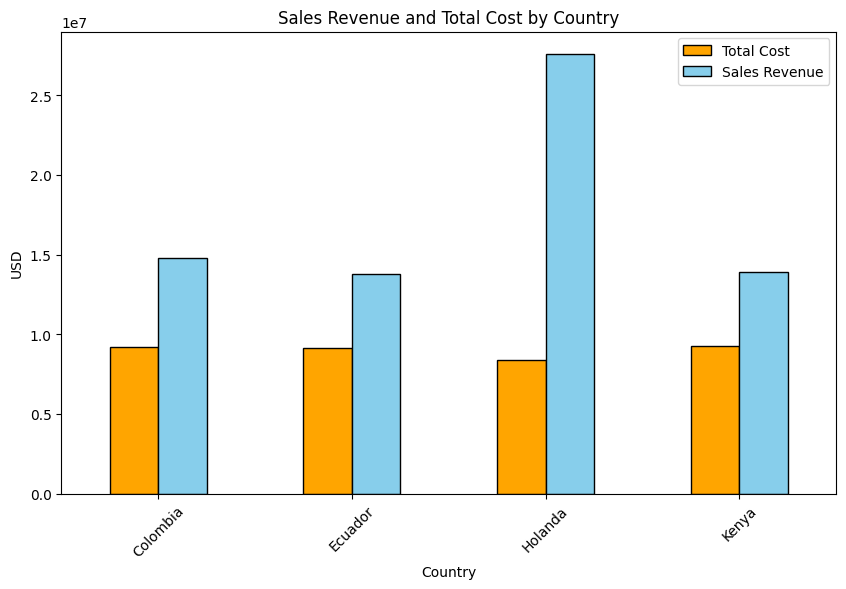

In [108]:

profit_country.plot(
    x='pais',
    y=['costo_total', 'sales_revenue'],
    kind='bar',
    stacked=False,
    figsize=(10,6),
    color=['orange', 'skyblue'],
    edgecolor='black'
)

plt.title('Sales Revenue and Total Cost by Country')
plt.xlabel('Country')
plt.ylabel('USD')
plt.xticks(rotation=45)
plt.legend(['Total Cost', 'Sales Revenue'])

plt.show()

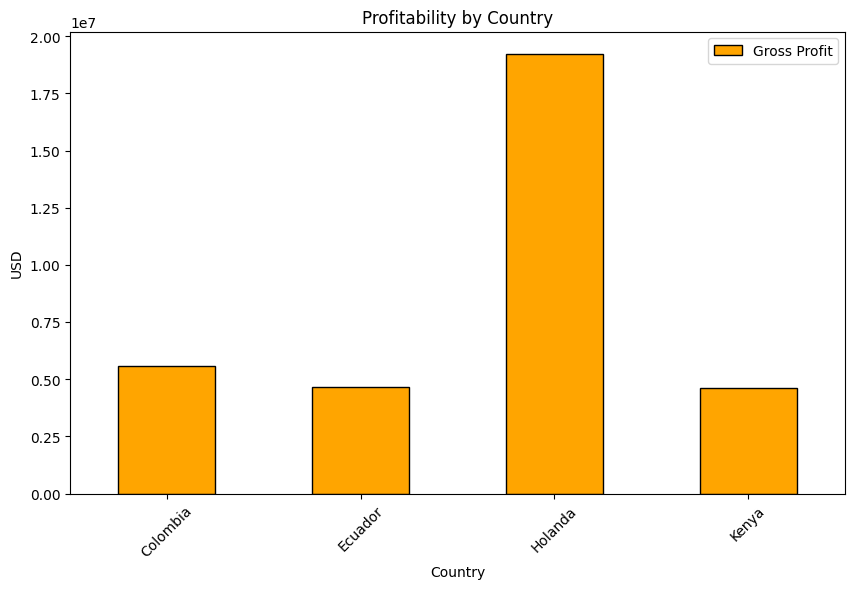

In [109]:

profit_country.plot(
    x='pais',
    y=['gross_profit'],
    kind='bar',
    stacked=False,
    figsize=(10,6),
    color=['orange', 'skyblue'],
    edgecolor='black'
)

plt.title('Profitability by Country')
plt.xlabel('Country')
plt.ylabel('USD')
plt.xticks(rotation=45)
plt.legend(['Gross Profit'])

plt.show()

**🧩CONCLUSIONES:**
- Se evidencia que Holanda fue el pais con mayor utilidad con 19'242.059 USD y los costos estuvieron entre 9.2 y 8.3 millones de USD lo cual fue muy parejo entre paises. Por tal razon **la utilidad de Holanda fue 25.7% mayor que Ecuador, Kenya y Colombia.**
- A nivel global las utilidades de toda la compañia fueron del 21% en 2023 y ha tenido una tendencia ha disminuir en el 2024 y 2025 con utilidadesdes del 16  y 12 % respectivamente.
- Los costos de Kenya, Colombia, Ecuador y Holanda son relativamente parecidos entre 9.2 millones y 8.3 millones mientras que las ventas de Holanda son 27 millones contra 13 millones promedio de Kenya, Colombia y Ecuador por tal razon los porcentajes de utilidades en Holnada con mayores debido a que Los procesos de Holanda son mas tecnificados y los precios de productos son mayor por ventajas en la tasa de cambio del Euro en Holanda.

In [110]:
sales_final.head()

,sales_order_number,sales_revenue,Year,production_cost_usd,pais,product_reference,campaign_id,Disposal_waste_cost,costo_total
0,SO-000001,52807.07,2023,51180.4,Kenya,Chrysal Protect Y,Influencers Agro,375.160,51555.560
1,SO-000002,93797.01,2024,50638.4,Colombia,Chrysal Grow X,Email marketing,104.970,50743.370
2,SO-000003,77864.99,2024,51530.7,Kenya,Chrysal Root R,Social Media,441.245,51971.945
3,SO-000004,30000.00,2024,51272.5,Kenya,Chrysal Grow X,Social Media,491.280,51763.780
4,SO-000005,70709.19,2024,51151.0,Holanda,Chrysal Root R,Field campaign,291.240,51442.240


In [111]:
marketing_clean.rename(columns={'Campaign_ID': 'campaign_id'}, inplace=True)
marketing_clean.head()

,Marketing_cost,campaign_id,Marketing_campaign_type
0,11000.0,Social Media,Social Media
1,3000.0,Influencers Agro,Influencers Agro
2,60000.0,Field campaign,Field Campaign
3,4000.0,Email marketing,Email Marketing


## **Calculo de "Profits" usando SQL**



In [112]:
import sqlite3

conn = sqlite3.connect(":memory:")

sales_final.to_sql(
    "chrysal_sales",
    conn,
    index=False,
    if_exists="replace"
)

700

In [113]:
# Explorar filtro Coolombia

query = """
SELECT *
FROM chrysal_sales

"""

resultado = pd.read_sql_query(query, conn)

resultado.head()

,sales_order_number,sales_revenue,Year,production_cost_usd,pais,product_reference,campaign_id,Disposal_waste_cost,costo_total
0,SO-000001,52807.07,2023,51180.4,Kenya,Chrysal Protect Y,Influencers Agro,375.160,51555.560
1,SO-000002,93797.01,2024,50638.4,Colombia,Chrysal Grow X,Email marketing,104.970,50743.370
2,SO-000003,77864.99,2024,51530.7,Kenya,Chrysal Root R,Social Media,441.245,51971.945
3,SO-000004,30000.00,2024,51272.5,Kenya,Chrysal Grow X,Social Media,491.280,51763.780
4,SO-000005,70709.19,2024,51151.0,Holanda,Chrysal Root R,Field campaign,291.240,51442.240


In [114]:
# Profits por pais

query = """
SELECT DISTINCT
    pais,
    SUM(sales_revenue) AS Total_sales,
    SUM(costo_total) AS Total_costs,
    Round(SUM(sales_revenue)-SUM(costo_total),1) AS Profits
FROM chrysal_sales
where sales_revenue is not null
GROUP BY pais

"""

resultado = pd.read_sql_query(query, conn)

resultado.head()

,pais,Total_sales,Total_costs,Profits
0,Colombia,14766534.49,9201402.390,5565132.1
1,Ecuador,13789037.29,9145226.965,4643810.3
2,Holanda,27616159.35,8374099.520,19242059.8
3,Kenya,13896479.66,9267169.050,4629310.6


In [115]:
# SUM(uvb.valor_booking) - SUM(COALESCE(ucv.costo_total, 0)) AS gross_profit

# Profit percentage per pais

query = """
SELECT DISTINCT
    pais,
    SUM(sales_revenue) AS Total_sales,
    SUM(costo_total) AS Total_costs,
    Round(SUM(sales_revenue)-SUM(costo_total),1) AS Profits,
    (Round(SUM(sales_revenue)-SUM(costo_total),1) * 100.0) / NULLIF(SUM(sales_revenue), 0) AS Percent_profit
FROM chrysal_sales
where sales_revenue is not null
GROUP BY pais

"""

resultado = pd.read_sql_query(query, conn)

resultado.head()

,pais,Total_sales,Total_costs,Profits,Percent_profit
0,Colombia,14766534.49,9201402.390,5565132.1,37.687462
1,Ecuador,13789037.29,9145226.965,4643810.3,33.677553
2,Holanda,27616159.35,8374099.520,19242059.8,69.676813
3,Kenya,13896479.66,9267169.050,4629310.6,33.312830


## **Cálculo de ROI con SQL (CTE + CASE WHEN)**

Uso una CTE para agregar ventas y costos de marketing por separado (evitando el efecto fan-out de un JOIN directo), calculo el % de ROI por campaña y clasifico cada campaña con `CASE WHEN` en 'Alto ROI', 'ROI Positivo Moderado', 'ROI Negativo' o 'Sin dato de marketing' cuando no hay costo de campaña registrado.


In [116]:
# Registro la tabla de marketing en la misma base SQLite en memoria
marketing_clean.to_sql(
    "chrysal_marketing",
    conn,
    index=False,
    if_exists="replace"
)


4

In [126]:
query = """
WITH sales_agg AS (
    SELECT
        campaign_id,
        SUM(sales_revenue) AS Total_sales,
        SUM(costo_total) AS Total_costo_producto
    FROM chrysal_sales
    WHERE sales_revenue IS NOT NULL
    GROUP BY campaign_id
),
marketing_agg AS (
    SELECT
        campaign_id,
        SUM(Marketing_cost) AS Total_marketing_cost
    FROM chrysal_marketing
    GROUP BY campaign_id
)
SELECT
    sa.campaign_id,
    sa.Total_sales,
    sa.Total_costo_producto,
    ma.Total_marketing_cost,
    ROUND(sa.Total_sales - sa.Total_costo_producto, 1) AS Profit,
    ROUND(
        (sa.Total_sales - sa.Total_costo_producto - ma.Total_marketing_cost) * 100.0
        / NULLIF(ma.Total_marketing_cost, 0), 1
    ) AS ROI_pct,
    CASE
        WHEN ma.Total_marketing_cost IS NULL OR ma.Total_marketing_cost = 0
            THEN 'Sin dato de marketing'
        WHEN (sa.Total_sales - sa.Total_costo_producto - ma.Total_marketing_cost) * 100.0
            / NULLIF(ma.Total_marketing_cost, 0) >= 50
            THEN 'Alto ROI'
        WHEN (sa.Total_sales - sa.Total_costo_producto - ma.Total_marketing_cost) * 100.0
            / NULLIF(ma.Total_marketing_cost, 0) >= 0
            THEN 'ROI Positivo Moderado'
        ELSE 'ROI Negativo'
    END AS ROI_segmento
FROM sales_agg sa
LEFT JOIN marketing_agg ma
    ON sa.campaign_id = ma.campaign_id
ORDER BY ROI_pct DESC
"""

resultado_roi = pd.read_sql_query(query, conn)
resultado_roi.head(10)


,campaign_id,Total_sales,Total_costo_producto,Total_marketing_cost,Profit,ROI_pct,ROI_segmento
0,Email marketing,1.992255e+07,9.250608e+06,4000.0,10671939.6,266698.5,Alto ROI
1,Influencers Agro,8.151388e+06,4.579992e+06,3000.0,3571395.1,118946.5,Alto ROI
2,Social Media,1.690778e+07,8.890880e+06,11000.0,8016899.3,72780.9,Alto ROI
3,Field campaign,2.508650e+07,1.326642e+07,60000.0,11820078.8,19600.1,Alto ROI


## **Uno tablas para calculo de ROI, (sales_final y marketing_clean)**

- La idea es incluir costos de campaña de marketing a la tabla de sales_final con la columna en comun "campaign_id"

In [118]:
# Incluyo la columna "campaign_id" para agrupar y despues poder unir a tabla de "marketing_clean"

profit_marketing= sales_final.groupby(['campaign_id']).agg(
    sales_revenue=('sales_revenue', 'sum'),
    costo_total=('costo_total', 'sum')
).reset_index()
profit_marketing


,campaign_id,sales_revenue,costo_total
0,Email marketing,1.992255e+07,9.250608e+06
1,Field campaign,2.508650e+07,1.326642e+07
2,Influencers Agro,8.151388e+06,4.579992e+06
3,Social Media,1.690778e+07,8.890880e+06


In [119]:
# Incluyo la columna "campaign_id" para agrupar y despues poder unir a tabla de "marketing_clean"

profit_country_marketing = sales_final.groupby(['pais', 'campaign_id']).agg(
    sales_revenue=('sales_revenue', 'sum'),
    costo_total=('costo_total', 'sum')
).reset_index()
profit_country_marketing


,pais,campaign_id,sales_revenue,costo_total
0,Colombia,Email marketing,3.449519e+06,2154117.010
1,Colombia,Field campaign,5.770152e+06,3599215.555
2,Colombia,Influencers Agro,1.364109e+06,921858.895
3,Colombia,Social Media,4.182753e+06,2526210.930
4,Ecuador,Email marketing,3.794205e+06,2774325.400
5,Ecuador,Field campaign,5.049528e+06,3182384.975
6,Ecuador,Influencers Agro,1.355675e+06,877893.985
7,Ecuador,Social Media,3.589631e+06,2310622.605
8,Holanda,Email marketing,8.988233e+06,2103640.930
9,Holanda,Field campaign,9.376921e+06,3084194.085


In [120]:
profit_country_marketing['profit'] = profit_country_marketing['sales_revenue'] - profit_country_marketing['costo_total']
profit_country_marketing

,pais,campaign_id,sales_revenue,costo_total,profit
0,Colombia,Email marketing,3.449519e+06,2154117.010,1.295402e+06
1,Colombia,Field campaign,5.770152e+06,3599215.555,2.170937e+06
2,Colombia,Influencers Agro,1.364109e+06,921858.895,4.422503e+05
3,Colombia,Social Media,4.182753e+06,2526210.930,1.656542e+06
4,Ecuador,Email marketing,3.794205e+06,2774325.400,1.019879e+06
5,Ecuador,Field campaign,5.049528e+06,3182384.975,1.867143e+06
6,Ecuador,Influencers Agro,1.355675e+06,877893.985,4.777806e+05
7,Ecuador,Social Media,3.589631e+06,2310622.605,1.279008e+06
8,Holanda,Email marketing,8.988233e+06,2103640.930,6.884592e+06
9,Holanda,Field campaign,9.376921e+06,3084194.085,6.292727e+06


In [121]:
profit_marketing['profit'] = profit_country_marketing['sales_revenue'] - profit_country_marketing['costo_total']
profit_marketing

,campaign_id,sales_revenue,costo_total,profit
0,Email marketing,1.992255e+07,9.250608e+06,1.295402e+06
1,Field campaign,2.508650e+07,1.326642e+07,2.170937e+06
2,Influencers Agro,8.151388e+06,4.579992e+06,4.422503e+05
3,Social Media,1.690778e+07,8.890880e+06,1.656542e+06


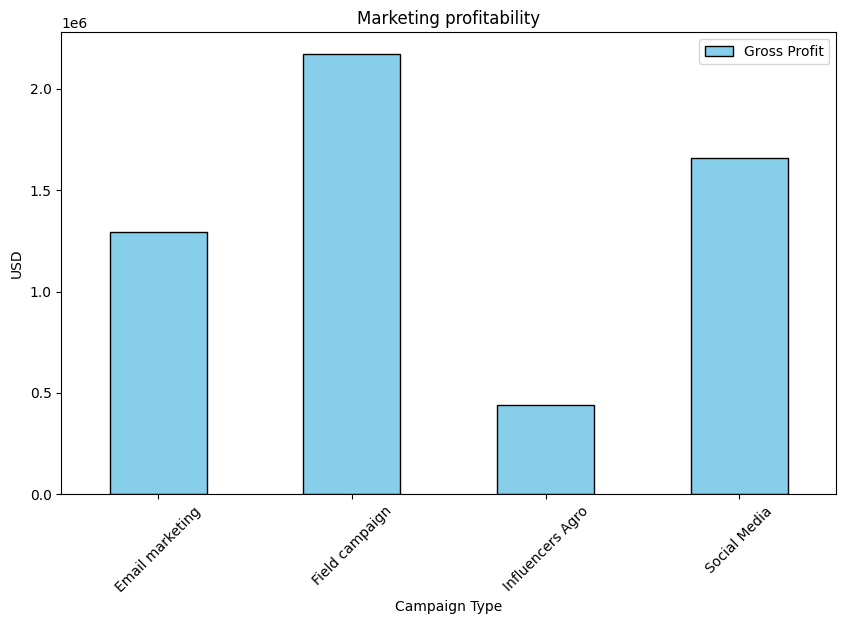

In [122]:
profit_marketing.plot(
    x='campaign_id',
    y=['profit'],
    kind='bar',
    stacked=False,
    figsize=(10,6),
    color=['skyblue'],
    edgecolor='black'
)

plt.title('Marketing profitability')
plt.xlabel('Campaign Type')
plt.ylabel('USD')
plt.xticks(rotation=45)
plt.legend(['Gross Profit'])

plt.show()

## **Agrupar ROI por pais y producto y ver pruebas de hipotesis posibles**

### Prueba T student para comparacion de promedios
Hipótesis:

- Hipótesis nula (H₀): No hay evidencia de diferencia significativa entre promedios de gastos entre página A y B.
- Hipótesis alternativa (H₁): Hay evidencia de diferencia significativa entre promedios de gastos entre página A y B.


In [123]:
# Diferencia estadistica entre campañas de marketing

from scipy.stats import ttest_ind

# Calculate profit per sale in sales_final
sales_final['profit_per_sale'] = sales_final['sales_revenue'] - sales_final['costo_total']

# Filter individual profit values for each campaign
Email_marketing_profits = sales_final[sales_final['campaign_id'] == 'Email marketing']['profit_per_sale']
Field_campaign_profits = sales_final[sales_final['campaign_id'] == 'Field campaign']['profit_per_sale']
Influencers_agro_profits = sales_final[sales_final['campaign_id'] == 'Influencers Agro']['profit_per_sale']
Social_media_profits = sales_final[sales_final['campaign_id'] == 'Social Media']['profit_per_sale']

# Perform t-test on distributions of profits
# Diferencia estadistica entgre campaña de E-mail_marketing y Field_campaign campaigns
t_statistic, p_value = ttest_ind(Email_marketing_profits, Field_campaign_profits)
print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

alpha = 0.05   # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia significativa en la rentabilidad por venta entre las campañas.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia significativa en la rentabilidad por venta entre las campañas.")

T-statistic: 1.7840863495260828
P-value: 0.07510496104425277
No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia significativa en la rentabilidad por venta entre las campañas.


In [124]:
# Diferencia estadistica entgre campaña de marketing de Field_campaign e Influencers Agro

t_statistic, p_value = ttest_ind(Field_campaign_profits, Influencers_agro_profits)
print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

alpha = 0.05   # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia significativa en la rentabilidad por venta entre las campañas.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia significativa en la rentabilidad por venta entre las campañas.")


T-statistic: 0.6646046864494287
P-value: 0.5067473424692177
No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia significativa en la rentabilidad por venta entre las campañas.


### **CONCLUSIONES**

- No hay diferencia significativa entre Profits de diferentes campañas de marketing pues P value es mayor a 0.05 al comparar todas las campañas entre si. Sin embargo la **"field_campaign" represento 800 mil dolares mas en utilidades que Email y Social Media. Con respecto a "influencers agro", "field campaigns" incremento 1.8 millones el "profit"**, evidenciando que el acompañamiento en campo es el mas efectivo.

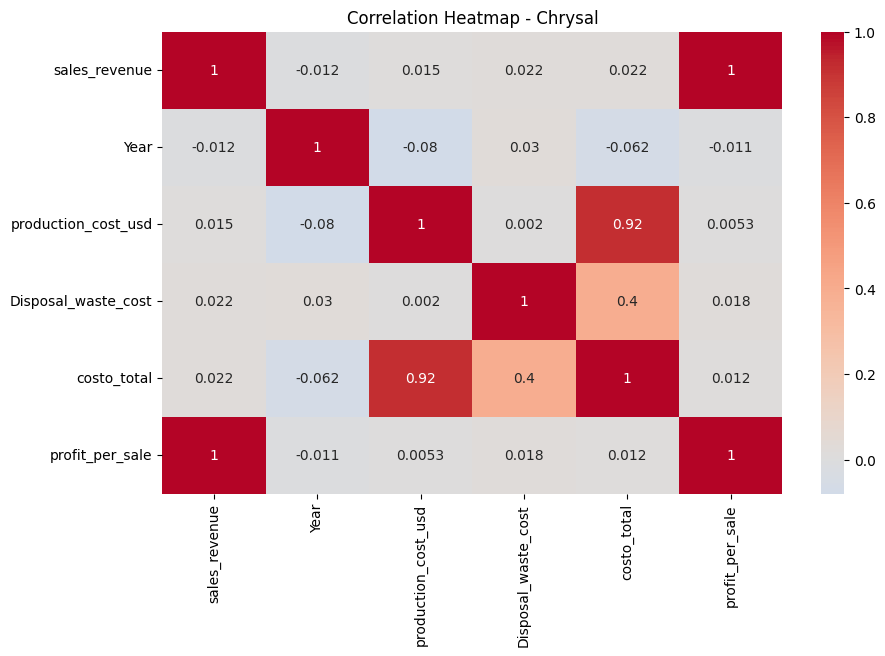

In [125]:
numeric_sales_final = sales_final.select_dtypes(include=np.number)
corr_matrix = numeric_sales_final.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Chrysal")
plt.show()

**🎯CONCLUSIONES:**
- En este analisis hay varias variables calculadas entre si como "costo_total" y "sales_revenue_usd" para calcular "gross_profit" y "margin_pct" por tal razon hay relacion entre variables porque son provenientes de calculos entre ellas mismas.
- Es importante mencionar que las ventas "sales_revenue_usd" y "profict_per _sale" tienen una relacion fuerte positiva con un coeficiente de correlacion de 1.0
-  Se evidencia que "production_cost" y "waste_cost" y "Disposal_waste_cost" tienen coeficientes medios y altos porque lo que hay calculos interrelacionados entre ellos.

## **Power BI - Dashboard**

https://drive.google.com/file/d/1wDPtB1jo_wB7MNByRHLTODpZ2-I36s1D/view?usp=sharing

